In [21]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [22]:
# Set style for better plots
sns.set(style="whitegrid")
%matplotlib inline

In [23]:
# Load the dataset (automatically downloads if needed)
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [24]:
# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [25]:
print("\nDataset Description:")
print(housing.DESCR)


Dataset Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census

In [26]:

print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        


Target Distribution:


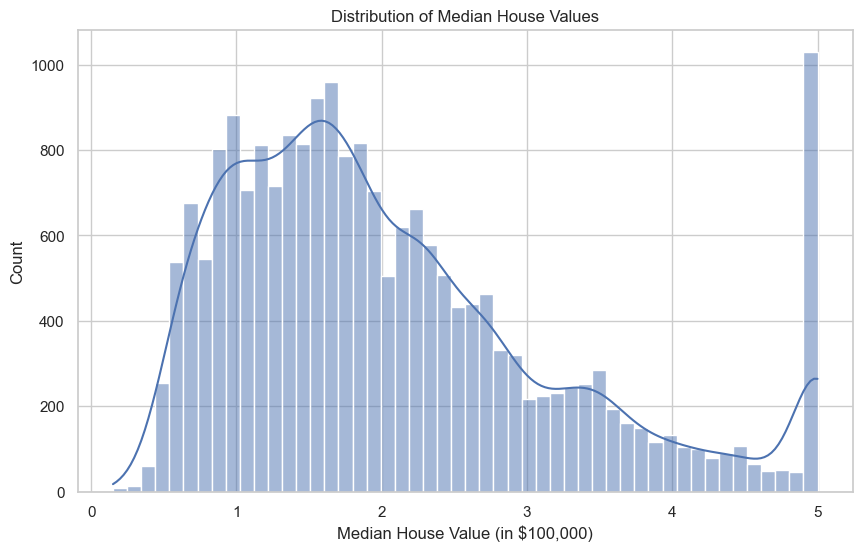

In [27]:
# Target variable: Median House Value (in $100,000s)
print("\nTarget Distribution:")
plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value (in $100,000)')
plt.show()

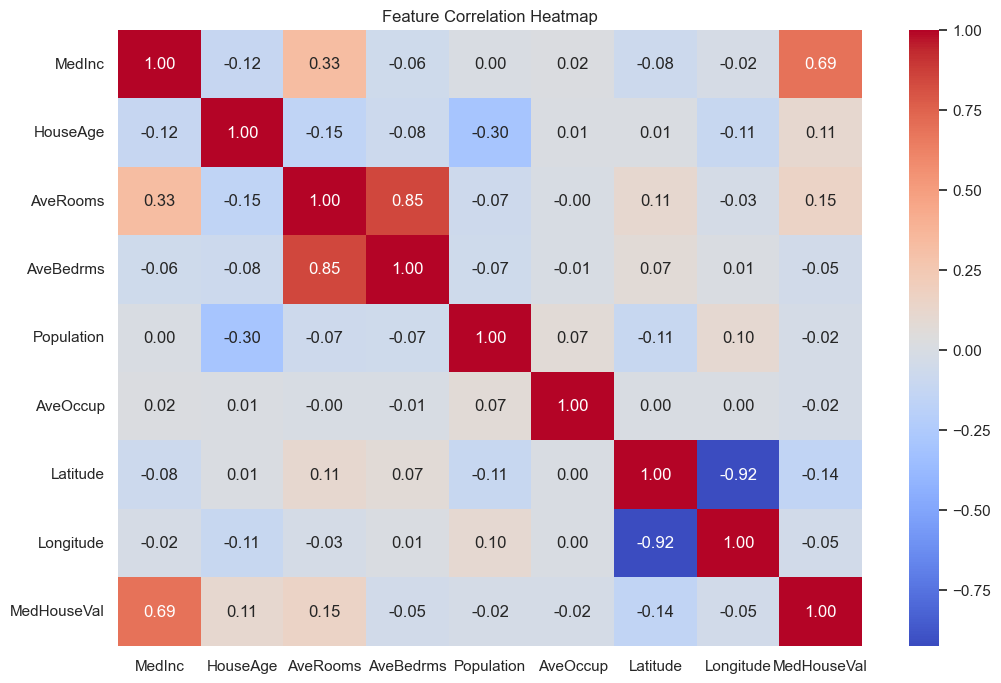

In [28]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

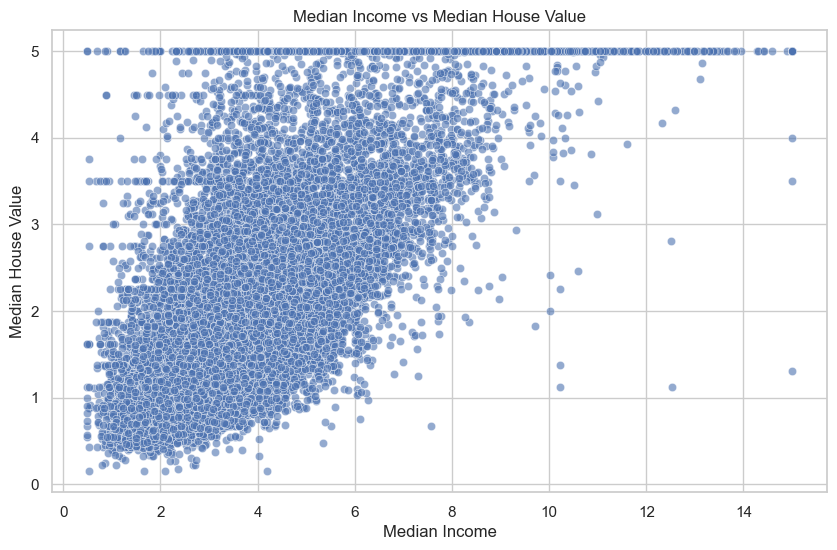

In [29]:
# Key scatter plots
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df, alpha=0.6)
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

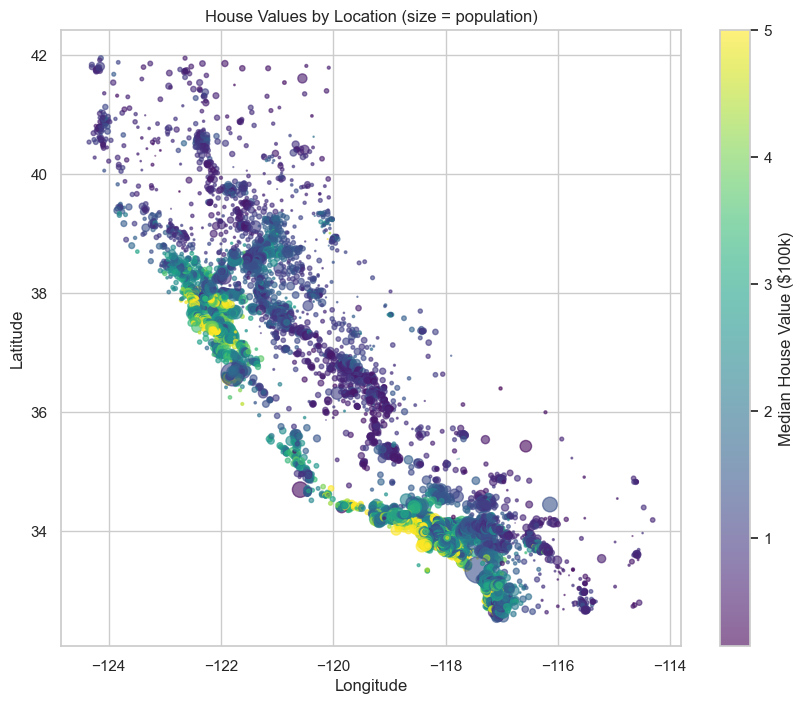

In [30]:
# Geographic plot (California map-like)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'], 
                      c=df['MedHouseVal'], s=df['Population']/100, 
                      cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Median House Value ($100k)')
plt.title('House Values by Location (size = population)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [44]:
# Feature Engineering: Add useful ratio features
df['RoomsPerHousehold'] = df['AveRooms'] / df['Households']
df['BedroomsPerHousehold'] = df['AveBedrms'] / df['Households']
df['PopulationPerHousehold'] = df['Population'] / df['Households']

In [32]:
# Prepare features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [33]:
# Optional: Scale features (helpful for some models, but Random Forest doesn't need it)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [36]:
# Predictions
y_pred = rf_model.predict(X_test)

In [38]:
# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nModel Performance on Test Set:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} (~${rmse * 100000:.0f})")
print(f"Mean Absolute Error (MAE): {mae:.4f} (~${mae * 100000:.0f})")
print(f"R² Score: {r2:.4f}")


Model Performance on Test Set:
Root Mean Squared Error (RMSE): 0.5040 (~$50396)
Mean Absolute Error (MAE): 0.3268 (~$32681)
R² Score: 0.8062


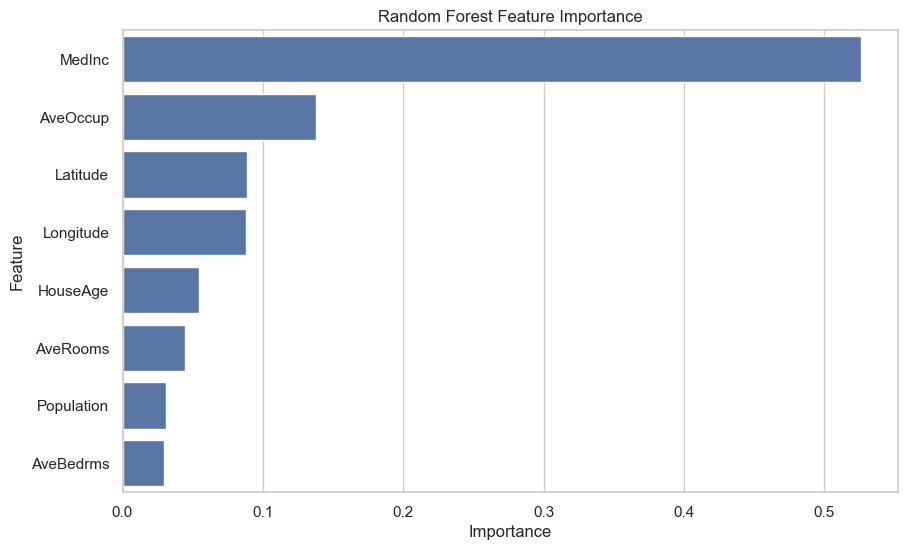

In [39]:
# Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.show()

In [41]:
#Example prediction
sample = X_test.iloc[0:1]  # First test sample
predicted_value = rf_model.predict(sample)[0]
actual_value = y_test.iloc[0]

print(f"\nExample Prediction:")
print(f"Actual Median House Value: ${actual_value * 100000:.0f}")
print(f"Predicted Median House Value: ${predicted_value * 100000:.0f}")


Example Prediction:
Actual Median House Value: $47700
Predicted Median House Value: $49443
